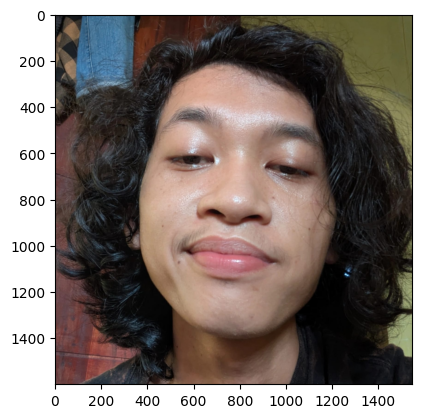

In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("assets_ws4/selfie.jpeg")

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.imshow(img_rgb)
plt.show()

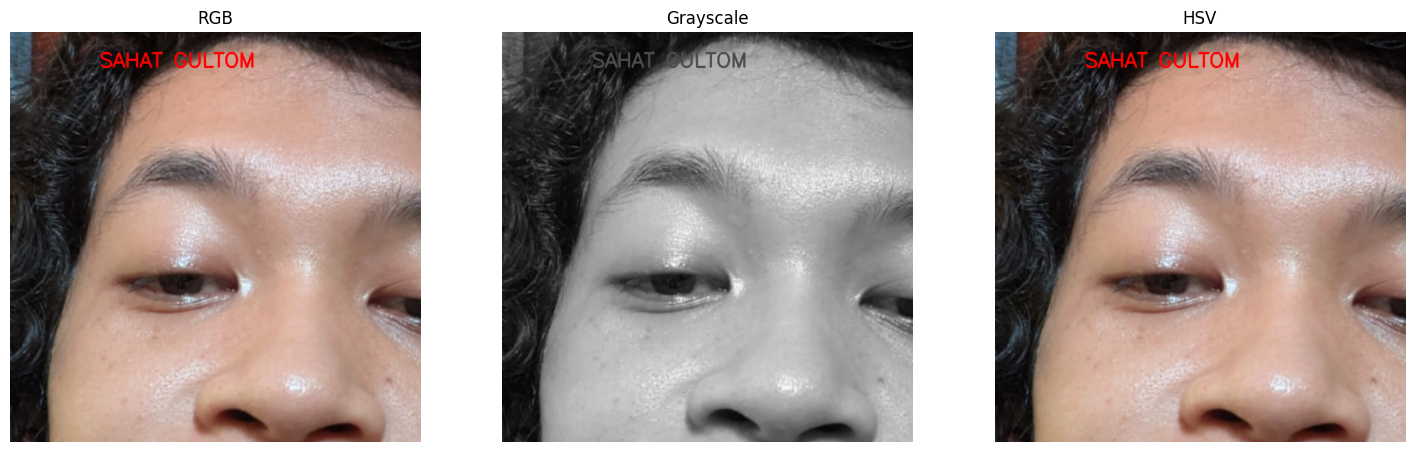

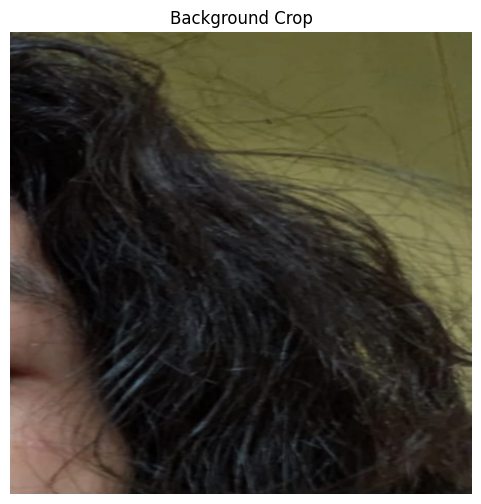

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("assets_ws4/selfie.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Crop wajah
face_crop = img_rgb[200:900, 300:1000]

# Crop background
background_crop = img_rgb[100:900, 1100:1800]

# Resize
face_resize = cv2.resize(face_crop, (920,920))
background_resize = cv2.resize(background_crop, (920,920))

# Tambah nama
img_annotated = face_resize.copy()

cv2.putText(
    img_annotated,
    "SAHAT GULTOM",
    (200,80),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.5,
    (255,0,0),
    3
)

# Grayscale
img_gray = cv2.cvtColor(
    img_annotated,
    cv2.COLOR_RGB2GRAY
)

# HSV
img_hsv = cv2.cvtColor(
    img_annotated,
    cv2.COLOR_RGB2HSV
)

img_hsv_display = cv2.cvtColor(
    img_hsv,
    cv2.COLOR_HSV2RGB
)

fig, ax = plt.subplots(1,3,figsize=(18,6))

ax[0].imshow(img_annotated)
ax[0].set_title("RGB")
ax[0].axis("off")

ax[1].imshow(img_gray,cmap="gray")
ax[1].set_title("Grayscale")
ax[1].axis("off")

ax[2].imshow(img_hsv_display)
ax[2].set_title("HSV")
ax[2].axis("off")

plt.show()

plt.figure(figsize=(6,6))
plt.imshow(background_resize)
plt.title("Background Crop")
plt.axis("off")
plt.show()

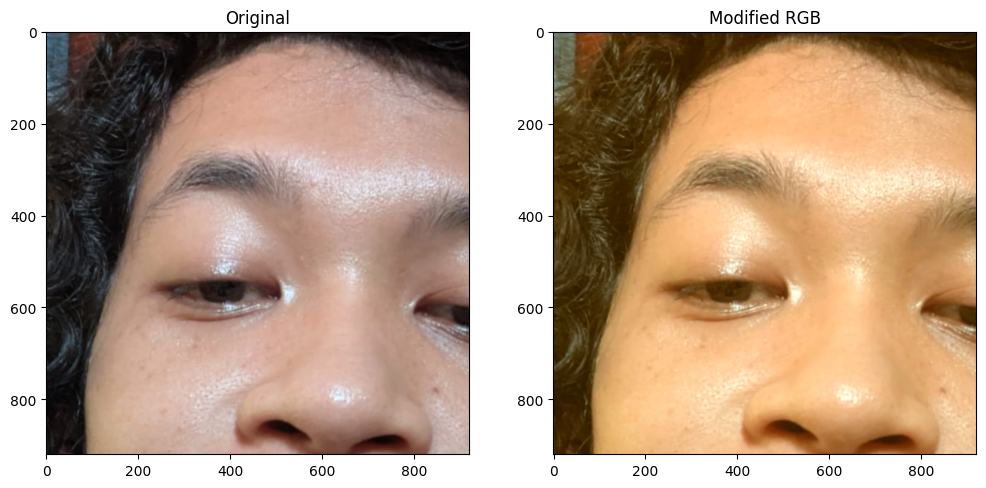

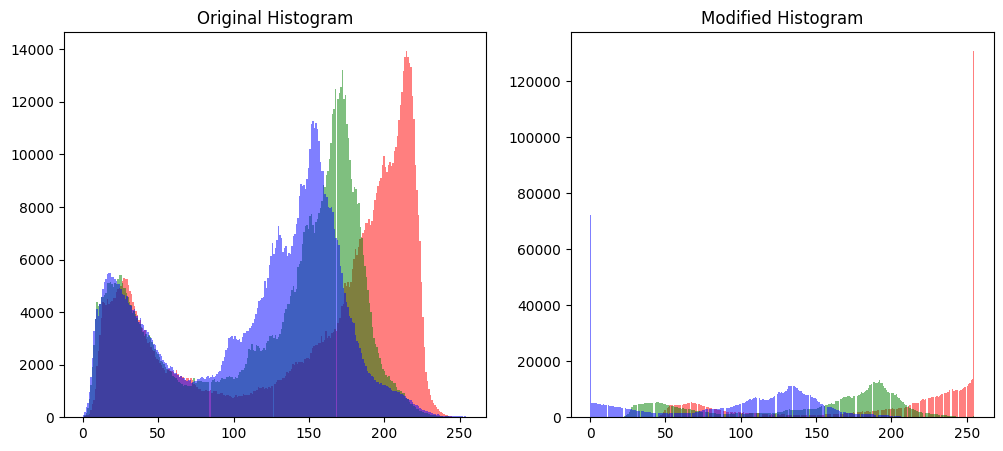

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("assets_ws4/selfie.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_crop = img_rgb[200:900,300:1000]
img_crop = cv2.resize(img_crop,(920,920))

R = img_crop[:,:,0].astype(np.int32)
G = img_crop[:,:,1].astype(np.int32)
B = img_crop[:,:,2].astype(np.int32)

R = np.clip(R+40,0,255)
G = np.clip(G+20,0,255)
B = np.clip(B-20,0,255)

img_modified = np.stack(
    [R,G,B],
    axis=2
).astype(np.uint8)

cv2.imwrite(
    "results_ws4/hasil_modifikasi_rgb.png",
    cv2.cvtColor(
        img_modified,
        cv2.COLOR_RGB2BGR
    )
)

fig, ax = plt.subplots(1,2,figsize=(12,6))

ax[0].imshow(img_crop)
ax[0].set_title("Original")

ax[1].imshow(img_modified)
ax[1].set_title("Modified RGB")

plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.hist(img_crop[:,:,0].ravel(),256,color='red',alpha=0.5)
plt.hist(img_crop[:,:,1].ravel(),256,color='green',alpha=0.5)
plt.hist(img_crop[:,:,2].ravel(),256,color='blue',alpha=0.5)

plt.title("Original Histogram")

plt.subplot(1,2,2)

plt.hist(img_modified[:,:,0].ravel(),256,color='red',alpha=0.5)
plt.hist(img_modified[:,:,1].ravel(),256,color='green',alpha=0.5)
plt.hist(img_modified[:,:,2].ravel(),256,color='blue',alpha=0.5)

plt.title("Modified Histogram")

plt.show()

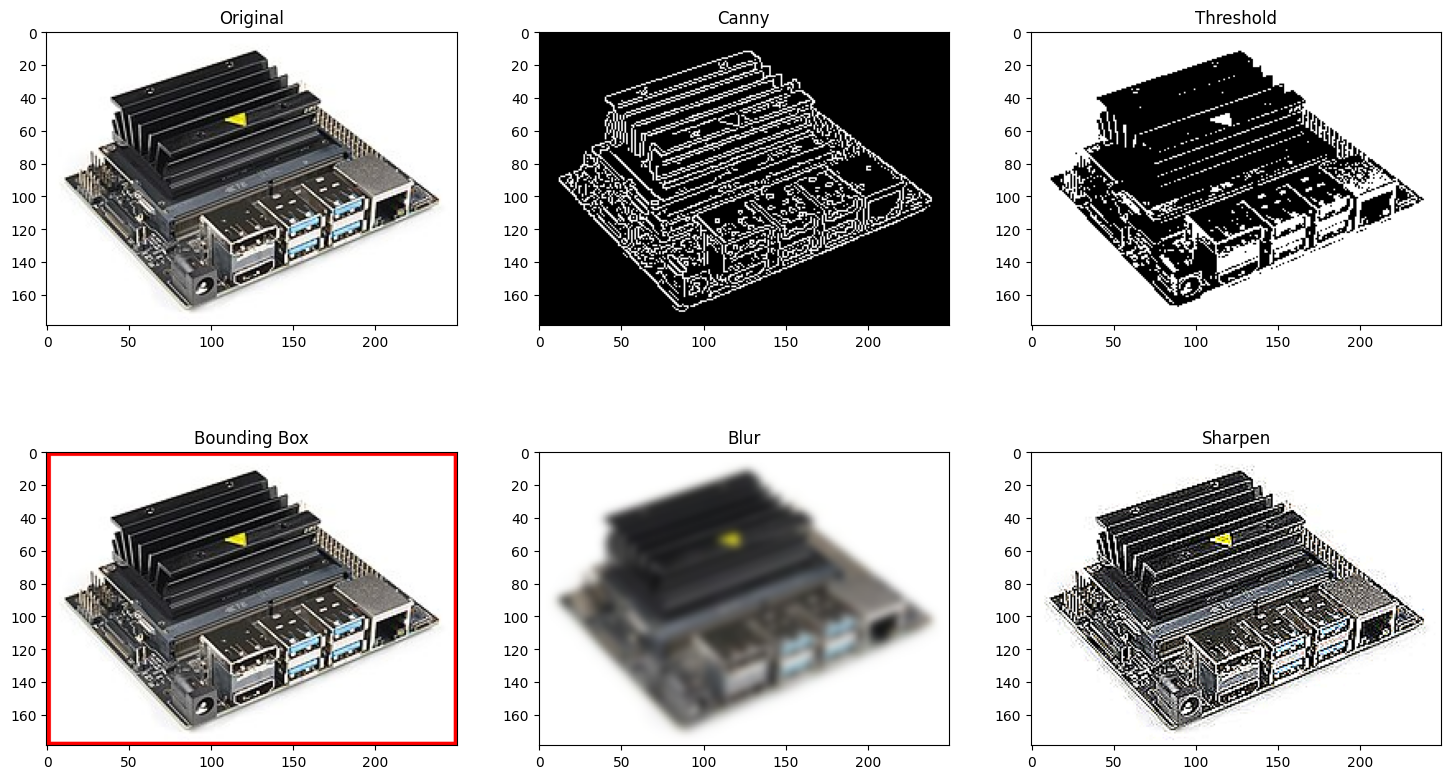

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("assets_ws4/jetson.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(
    gray,
    80,
    180
)

_, thresh = cv2.threshold(
    gray,
    120,
    255,
    cv2.THRESH_BINARY
)

contours,_ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

img_bbox = img_rgb.copy()

for c in contours:

    area = cv2.contourArea(c)

    if area > 1000:

        x,y,w,h = cv2.boundingRect(c)

        cv2.rectangle(
            img_bbox,
            (x,y),
            (x+w,y+h),
            (255,0,0),
            3
        )

img_blur = cv2.GaussianBlur(
    img_rgb,
    (15,15),
    0
)

kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
])

img_sharp = cv2.filter2D(
    img_rgb,
    -1,
    kernel
)

fig, ax = plt.subplots(2,3,figsize=(18,10))

ax[0,0].imshow(img_rgb)
ax[0,0].set_title("Original")

ax[0,1].imshow(edges,cmap="gray")
ax[0,1].set_title("Canny")

ax[0,2].imshow(thresh,cmap="gray")
ax[0,2].set_title("Threshold")

ax[1,0].imshow(img_bbox)
ax[1,0].set_title("Bounding Box")

ax[1,1].imshow(img_blur)
ax[1,1].set_title("Blur")

ax[1,2].imshow(img_sharp)
ax[1,2].set_title("Sharpen")

plt.show()

In [8]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

img = cv2.imread("assets_ws4/reddevil.jpeg")
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1
)

results = face_mesh.process(img_rgb)

img_filter = img_rgb.copy()

if results.multi_face_landmarks:

    h,w,_ = img_rgb.shape

    for face in results.multi_face_landmarks:

        left_eye = face.landmark[33]
        right_eye = face.landmark[263]
        nose = face.landmark[1]

        lx = int(left_eye.x*w)
        ly = int(left_eye.y*h)

        rx = int(right_eye.x*w)
        ry = int(right_eye.y*h)

        nx = int(nose.x*w)
        ny = int(nose.y*h)

        cv2.circle(img_filter,(lx,ly),40,(0,255,0),4)
        cv2.circle(img_filter,(rx,ry),40,(0,255,0),4)

        cv2.line(
            img_filter,
            (lx+40,ly),
            (rx-40,ry),
            (0,255,0),
            4
        )

        cv2.rectangle(
            img_filter,
            (nx-60,ny+20),
            (nx+60,ny+80),
            (255,0,0),
            -1
        )

fig, ax = plt.subplots(1,2,figsize=(15,7))

ax[0].imshow(img_rgb)
ax[0].set_title("Original")

ax[1].imshow(img_filter)
ax[1].set_title("Creative Filter")

plt.show()

ModuleNotFoundError: No module named 'mediapipe'